# 05. Transformer Architecture

**Tier:** Foundations
**Estimated time:** 60 minutes
**Prerequisites:** 00–04
**Source material:** "Attention Is All You Need" (Vaswani et al., 2017); Stanford LLM curriculum, Lecture 1

## What You'll Learn
- The four ingredients of a transformer block: **multi-head attention, a feed-forward network, residual connections, and layer normalization**
- Why a transformer needs **positional encodings** (attention itself is order-blind)
- How stacking identical blocks into a **GPT-style decoder** turns token IDs into next-token predictions — built from scratch in PyTorch

## Why This Matters
Every LLM you'll use — GPT, Claude, Llama — is this one block repeated dozens to hundreds of times, scaled up. Once you can build the block and trace a tensor through it, "the model" stops being a black box. This is the architecture the entire Training tier (notebooks 07–11) optimizes, compresses, and fine-tunes.

## The block, in plain English

A transformer block takes a sequence of token vectors and returns an *improved* sequence of the same shape. It does two things, each wrapped in a safety harness:

1. **Mix across tokens** — multi-head self-attention (notebook 04) lets each token gather context from the others.
2. **Think per token** — a small feed-forward network (FFN) processes each token's vector independently, adding nonlinear "compute."

The harness around each step is two tricks that make deep stacks trainable:
- **Residual connection** (`x + sublayer(x)`): add the input back to the output, so information and gradients flow straight through. Without it, deep networks don't train.
- **Layer normalization**: rescale each token vector to a stable mean/variance, keeping numbers well-behaved layer after layer.

One more piece sits *before* the blocks: **positional encoding**. Attention treats its input as an unordered set — "the cat" and "cat the" look identical to it. So we add a position signal to each token's embedding to tell the model where each word sits.

In [1]:
import torch
import torch.nn as nn
import numpy as np

torch.manual_seed(0)

def pick_device():
    if torch.cuda.is_available(): return torch.device("cuda")
    if torch.backends.mps.is_available(): return torch.device("mps")
    return torch.device("cpu")

device = pick_device()
print("Device:", device)

Device: mps


## Positional encoding

The original transformer uses fixed **sinusoidal** encodings: each position gets a unique pattern of sines and cosines at different frequencies. Nearby positions get similar patterns, and the model can learn relative offsets from them. (Modern models often use learned or rotary positions — notebook covers RoPE later — but sinusoids are the clearest place to start.)

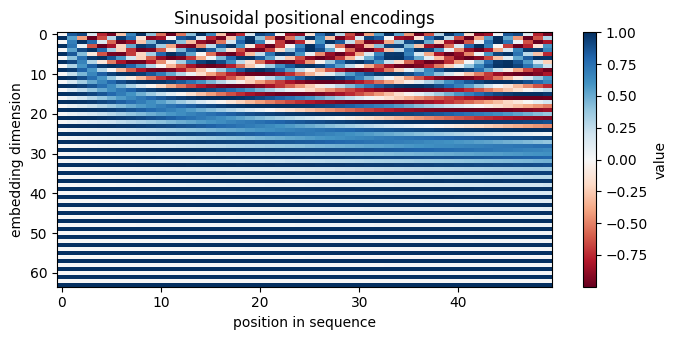

In [2]:
def sinusoidal_encoding(seq_len, d_model):
    pos = np.arange(seq_len)[:, None]                  # (seq_len, 1)
    i = np.arange(d_model)[None, :]                    # (1, d_model)
    angle_rates = 1 / np.power(10000, (2 * (i // 2)) / d_model)
    angles = pos * angle_rates
    pe = np.zeros((seq_len, d_model))
    pe[:, 0::2] = np.sin(angles[:, 0::2])              # even dims -> sine
    pe[:, 1::2] = np.cos(angles[:, 1::2])              # odd dims  -> cosine
    return pe

%matplotlib inline
import matplotlib.pyplot as plt
pe = sinusoidal_encoding(seq_len=50, d_model=64)
plt.figure(figsize=(7, 3.5))
plt.imshow(pe.T, aspect="auto", cmap="RdBu")
plt.xlabel("position in sequence"); plt.ylabel("embedding dimension")
plt.title("Sinusoidal positional encodings"); plt.colorbar(label="value")
plt.tight_layout(); plt.show()

*Each column is the unique 'fingerprint' added to the token at that position. Low dimensions wiggle slowly (coarse position), high dimensions wiggle fast (fine position) — together they pin down 'where am I?' for every token.*

## The transformer block in PyTorch

We use PyTorch's built-in `nn.MultiheadAttention` (you implemented its core from scratch in notebook 04) and wire up the FFN, residuals, and layer norms ourselves so the structure stays visible.

In [3]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, ff_mult=4, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        # Feed-forward network: expand to ff_mult x width, nonlinearity, project back.
        self.ff = nn.Sequential(
            nn.Linear(d_model, ff_mult * d_model),
            nn.GELU(),
            nn.Linear(ff_mult * d_model, d_model),
        )
        self.drop = nn.Dropout(dropout)

    def forward(self, x, attn_mask=None):
        # Pre-norm style: normalise, apply sublayer, add residual.
        normed = self.norm1(x)
        attn_out, _ = self.attn(normed, normed, normed, attn_mask=attn_mask, need_weights=False)
        x = x + self.drop(attn_out)                 # residual around attention
        x = x + self.drop(self.ff(self.norm2(x)))   # residual around feed-forward
        return x

block = TransformerBlock(d_model=64, n_heads=4)
sample = torch.randn(2, 10, 64)                     # (batch=2, seq=10, d_model=64)
print("in :", sample.shape)
print("out:", block(sample).shape, "  <- same shape, improved representations")

in : torch.Size([2, 10, 64])
out: torch.Size([2, 10, 64])   <- same shape, improved representations


## Stacking blocks into a GPT-style model

A decoder LLM is: token embedding + positional encoding → N transformer blocks (with a **causal mask** so each token only sees the past) → a final linear layer that produces a score for every token in the vocabulary (the **logits**). Sampling from those logits is how it generates text — the subject of notebook 06.

In [4]:
class TinyGPT(nn.Module):
    def __init__(self, vocab_size, d_model=64, n_heads=4, n_layers=3, max_len=128):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, d_model)
        pe = torch.tensor(sinusoidal_encoding(max_len, d_model), dtype=torch.float32)
        self.register_buffer("pos_emb", pe)         # fixed, not learned
        self.blocks = nn.ModuleList([TransformerBlock(d_model, n_heads) for _ in range(n_layers)])
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size)  # project to vocabulary logits

    def forward(self, token_ids):
        seq_len = token_ids.shape[1]
        x = self.token_emb(token_ids) + self.pos_emb[:seq_len]
        # Causal mask: True where attention is BLOCKED (the upper triangle = future tokens).
        mask = torch.triu(torch.ones(seq_len, seq_len, device=token_ids.device), diagonal=1).bool()
        for block in self.blocks:
            x = block(x, attn_mask=mask)
        return self.head(self.norm(x))              # (batch, seq, vocab_size)

vocab_size = 1000
model = TinyGPT(vocab_size).to(device)
dummy = torch.randint(0, vocab_size, (2, 12), device=device)   # 2 sequences of 12 token IDs
logits = model(dummy)
print("logits shape:", logits.shape, "= (batch, seq_len, vocab_size)")
print("Each of the", logits.shape[1], "positions gets a score for all", vocab_size, "possible next tokens.")

logits shape: torch.Size([2, 12, 1000]) = (batch, seq_len, vocab_size)
Each of the 12 positions gets a score for all 1000 possible next tokens.


In [5]:
# How big is our toy model? And how does it compare to real LLMs?
n_params = sum(p.numel() for p in model.parameters())
print(f"TinyGPT parameters: {n_params:,}")

print("\nFor scale (parameters):")
for name, p in [("Our TinyGPT", n_params), ("GPT-2 small", 124_000_000),
                ("GPT-3", 175_000_000_000), ("Llama-3 70B", 70_000_000_000)]:
    print(f"  {name:14s} {p:>18,}")

TinyGPT parameters: 279,080

For scale (parameters):
  Our TinyGPT               279,080
  GPT-2 small           124,000,000
  GPT-3             175,000,000,000
  Llama-3 70B        70,000,000,000


*Same architecture, wildly different scale. The leap from our toy to GPT-3 is mostly 'more layers, wider d_model, bigger vocab, vastly more data' — not a different idea. That's the lesson of the scaling laws in notebook 07.*

## Exercises

In [6]:
# Exercise 1 (Warm-up): Scale knobs
# Task: Build three TinyGPT models varying n_layers (2, 4, 8) and d_model (32, 64, 128),
#       and print the parameter count of each. Which knob grows the model fastest?
# Hint: Reuse sum(p.numel() for p in m.parameters()). Width (d_model) appears in many places.

# YOUR CODE HERE

In [7]:
# Exercise 2 (Apply): Inspect the residual stream
# Task: Modify TransformerBlock.forward to also return the L2 norm of x before and after
#       each residual add. Run one block and confirm the norm grows (residuals accumulate).
# Hint: x.norm(dim=-1).mean() gives an average vector length across the sequence.

# YOUR CODE HERE

In [8]:
# Exercise 3 (Extend): One generation step
# Task: Take the logits for the LAST position from model(dummy), apply softmax, and pick the
#       argmax token id. That single step, repeated, IS text generation (notebook 06).
# Hint: logits[:, -1, :] are the predictions for the next token after each sequence.

# YOUR CODE HERE

<details>
<summary>Show solutions</summary>

```python
# Exercise 1
for L in [2, 4, 8]:
    for d in [32, 64, 128]:
        m = TinyGPT(vocab_size, d_model=d, n_heads=4, n_layers=L)
        print(f"layers={L} d_model={d}: {sum(p.numel() for p in m.parameters()):,}")
# d_model dominates: it scales attention AND the FFN AND both embeddings (roughly quadratically).

# Exercise 3
import torch.nn.functional as F
last = model(dummy)[:, -1, :]            # (batch, vocab)
probs = F.softmax(last, dim=-1)
next_ids = probs.argmax(dim=-1)
print("greedy next token ids:", next_ids.tolist())
```
</details>

## Key Takeaways
- A transformer **block** = multi-head attention + feed-forward network, each wrapped in a **residual connection** and **layer norm**; input and output have the same shape.
- **Positional encodings** are added up front because attention alone is order-blind.
- A **GPT-style decoder** stacks N blocks with a **causal mask**, then projects to vocabulary **logits** — a next-token score for every position.
- Real LLMs are this exact architecture scaled up in depth, width, vocabulary, and data — not a fundamentally different design.

## What's Next
Notebook **06 — How LLMs Work** turns these logits into actual text: sampling, temperature, greedy vs. probabilistic decoding, and why models hallucinate.